<a href="https://colab.research.google.com/github/Ashleylq/credit-default-predictor/blob/main/notebooks/Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ucimlrepo pandas numpy scikit-learn matplotlib

# **Load Dataset**



In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

default_of_credit_card_clients = fetch_ucirepo(id=350)

X = default_of_credit_card_clients.data.features
y = default_of_credit_card_clients.data.targets.squeeze()

print(default_of_credit_card_clients.metadata)
print(default_of_credit_card_clients.variables)
print(X.shape)

{'uci_id': 350, 'name': 'Default of Credit Card Clients', 'repository_url': 'https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients', 'data_url': 'https://archive.ics.uci.edu/static/public/350/data.csv', 'abstract': "This research aimed at the case of customers' default payments in Taiwan and compares the predictive accuracy of probability of default among six data mining methods.", 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 30000, 'num_features': 23, 'feature_types': ['Integer', 'Real'], 'demographics': ['Sex', 'Education Level', 'Marital Status', 'Age'], 'target_col': ['Y'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Fri Mar 29 2024', 'dataset_doi': '10.24432/C55S3H', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 365, 'type': 'NATIVE', 'title': 'The comparisons of data mining techniques for the predictive accuracy of 

Replace the cryptic names

In [ ]:
feature_map = {
    'X1': 'LIMIT_BAL',
    'X2': 'SEX',
    'X3': 'EDUCATION',
    'X4': 'MARRIAGE',
    'X5': 'AGE',
    'X6': 'PAY_0',
    'X7': 'PAY_2',
    'X8': 'PAY_3',
    'X9': 'PAY_4',
    'X10': 'PAY_5',
    'X11': 'PAY_6',
    'X12': 'BILL_AMT1',
    'X13': 'BILL_AMT2',
    'X14': 'BILL_AMT3',
    'X15': 'BILL_AMT4',
    'X16': 'BILL_AMT5',
    'X17': 'BILL_AMT6',
    'X18': 'PAY_AMT1',
    'X19': 'PAY_AMT2',
    'X20': 'PAY_AMT3',
    'X21': 'PAY_AMT4',
    'X22': 'PAY_AMT5',
    'X23': 'PAY_AMT6'
}
X = X.rename(columns=feature_map)
X.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'],
      dtype='object')

# **Get Numerical and Categorical Columns**

In [ ]:
cat = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2',
        'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
num = X.drop(columns=cat).columns.tolist()
num, cat

(['LIMIT_BAL',
  'AGE',
  'BILL_AMT1',
  'BILL_AMT2',
  'BILL_AMT3',
  'BILL_AMT4',
  'BILL_AMT5',
  'BILL_AMT6',
  'PAY_AMT1',
  'PAY_AMT2',
  'PAY_AMT3',
  'PAY_AMT4',
  'PAY_AMT5',
  'PAY_AMT6'],
 ['SEX',
  'EDUCATION',
  'MARRIAGE',
  'PAY_0',
  'PAY_2',
  'PAY_3',
  'PAY_4',
  'PAY_5',
  'PAY_6'])

# **Prepare Preprocessing Functions**

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

enc_numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="median"))
])

enc_categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

encode_preprocessor = ColumnTransformer(transformers=[
    ('num', enc_numerical_transformer, num),
    ('cat', enc_categorical_transformer, cat)
])

In [ ]:
from sklearn.preprocessing import StandardScaler

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="median")),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

std_preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num),
    ('cat', categorical_transformer, cat)
])

In [ ]:
from sklearn.preprocessing import FunctionTransformer, PowerTransformer

def apply_log(X):
  skew = X.skew()
  skewed_columns = skew[skew.abs() > 1].index.tolist()
  copy = X.copy()
  pt = PowerTransformer(method="yeo-johnson")
  copy[skewed_columns] = pt.fit_transform(copy[skewed_columns])
  return copy

log_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="median")),
    ('log1p', FunctionTransformer(func=apply_log)),
    ('scaler', StandardScaler())
])

log_preprocessor = ColumnTransformer(transformers=[
    ('num', log_transformer, num),
    ('cat', categorical_transformer, cat)
])

log_preprocessor.set_output(transform="pandas")

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('log1p',
                                                  FunctionTransformer(func=<function apply_log at 0x78a9c4811c60>)),
                                                 ('scaler', StandardScaler())]),
                                 ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2',
                                  'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5',
                                  'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2',
                                  'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5',
                                  'PAY_AMT6']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0',
                                  'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5',
                                  'PAY_6'])])

# **Create Model Testing Function**

In [ ]:
from sklearn.model_selection import KFold, cross_validate

cv = KFold(n_splits=5, shuffle=True)

def conduct_experiment(model, preprocessor):
  metrics = ['precision', 'recall', 'f1', 'roc_auc']
  pipeline = Pipeline(steps=[
      ('preprocessor', preprocessor),
      ('model', model)
  ])
  cv_score = cross_validate(pipeline, X, y, cv=cv, scoring=metrics)
  print(f"roc auc: {cv_score["test_roc_auc"].mean()}")
  print(f"f1: {cv_score["test_f1"].mean()}")
  print(f"precision: {cv_score["test_precision"].mean()}")
  print(f"recall: {cv_score["test_recall"].mean()}")

# **Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
conduct_experiment(LogisticRegression(), std_preprocessor)

roc auc: 0.7685030903142549
f1: 0.4665413792948348
precision: 0.6802087398302695
recall: 0.3550959943147148


In [ ]:
conduct_experiment(LogisticRegression(max_iter=1000), log_preprocessor)

roc auc: 0.7758686683868689
f1: 0.47417025832108645
precision: 0.6746921554137947
recall: 0.3657923288725412


Log is slightly better but I had to increase the number of iterations to avoid a convergence warning.

# **Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
conduct_experiment(RandomForestClassifier(), encode_preprocessor)

NameError: name 'conduct_experiment' is not defined

In [ ]:
conduct_experiment(RandomForestClassifier(), log_preprocessor)

# **Hist Gradient Boosting Classifier**

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
conduct_experiment(HistGradientBoostingClassifier(), encode_preprocessor)

roc auc: 0.7840063802225198
f1: 0.47814897878155804
precision: 0.675642997027359
recall: 0.3700897891555198


In [ ]:
conduct_experiment(HistGradientBoostingClassifier(), log_preprocessor)

roc auc: 0.7687503268327844
f1: 0.4642387095120906
precision: 0.6724662066225469
recall: 0.355180508440718


Hist gradient boosting classifier with only encoding performed the best

# **Feature Engineering**

In [ ]:
def engineer_features(X):
  copy = X.copy()
  copy["TOTAL_BILL"] = copy["BILL_AMT1"] + copy["BILL_AMT2"] + copy["BILL_AMT3"] + copy["BILL_AMT4"] + copy["BILL_AMT5"] + copy["BILL_AMT6"]
  copy["TOTAL_PAY"] = copy["PAY_AMT1"] + copy["PAY_AMT2"] + copy["PAY_AMT3"] + copy["PAY_AMT4"] + copy["PAY_AMT5"] + copy["PAY_AMT6"]
  copy["PAY_TO_BILL_RATIO"] = copy["TOTAL_BILL"] / (copy["TOTAL_PAY"] + 1)
  return copy

eng_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("eng", FunctionTransformer(func=engineer_features))
])

eng_preprocessor = ColumnTransformer(transformers=[
    ("num", eng_transformer,  num),
    ("cat", enc_categorical_transformer, cat)
])

eng_preprocessor.set_output(transform="pandas")

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('eng',
                                                  FunctionTransformer(func=<function engineer_features at 0x7ba9d3dbb600>))]),
                                 ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2',
                                  'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5',
                                  'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2',
                                  'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5',
                                  'PAY_AMT6']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0',
                                  'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5',
                                  'PAY_6'])])

In [ ]:
conduct_experiment(HistGradientBoostingClassifier(), eng_preprocessor)

roc auc: 0.7820828048764067
f1: 0.47185357681597334
precision: 0.6721913604240802
recall: 0.3635537113642401


Hist Gradient Boosting Classifier with only one hot encoding performed the best

# **Train Test Split**

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# **Hyperparameter Tuning**

In [ ]:
model = Pipeline(steps=[
    ('preprocessor', encode_preprocessor),
    ('model', HistGradientBoostingClassifier(class_weight="balanced"))
])

model.get_params().keys()

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'preprocessor', 'model', 'preprocessor__force_int_remainder_cols', 'preprocessor__n_jobs', 'preprocessor__remainder', 'preprocessor__sparse_threshold', 'preprocessor__transformer_weights', 'preprocessor__transformers', 'preprocessor__verbose', 'preprocessor__verbose_feature_names_out', 'preprocessor__num', 'preprocessor__cat', 'preprocessor__num__memory', 'preprocessor__num__steps', 'preprocessor__num__transform_input', 'preprocessor__num__verbose', 'preprocessor__num__imputer', 'preprocessor__num__imputer__add_indicator', 'preprocessor__num__imputer__copy', 'preprocessor__num__imputer__fill_value', 'preprocessor__num__imputer__keep_empty_features', 'preprocessor__num__imputer__missing_values', 'preprocessor__num__imputer__strategy', 'preprocessor__cat__memory', 'preprocessor__cat__steps', 'preprocessor__cat__transform_input', 'preprocessor__cat__verbose', 'preprocessor__cat__imputer', 'preprocessor__cat__encoder', 'preprocess

In [ ]:
param_distributions = {
    "model__learning_rate" : [0.01, 0.03, 0.05, 0.1],
    "model__max_depth" : [3, 4, 5],
    "model__l2_regularization" : [0.0, 0.01, 0.1, 1, 10, 100],
    "model__min_samples_leaf" : [1, 2, 4],
    "model__max_bins" : [31, 63, 127, 255]
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
rs = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions,
    n_iter=50,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42)
rs.fit(X_train, y_train)
hp_tuned_model = rs.best_estimator_
rs.best_params_

{'model__min_samples_leaf': 1,
 'model__max_depth': 4,
 'model__max_bins': 127,
 'model__learning_rate': 0.1,
 'model__l2_regularization': 100}

# **Threshold Adjustment**

In [ ]:
from sklearn.model_selection import TunedThresholdClassifierCV
from sklearn.metrics import make_scorer, fbeta_score

scorer = make_scorer(fbeta_score, beta=1.5)
tuned_model = TunedThresholdClassifierCV(
    estimator = hp_tuned_model,
    scoring=scorer,
    cv="prefit",
    n_jobs=-1,
    refit=False
)
tuned_model.fit(X_test, y_test)
tuned_model.best_threshold_

np.float64(0.3689292523278752)

We will focus on increasing recall for this dataset

# **Evaluate Model**

In [ ]:
preds = tuned_model.predict(X_val)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_val, preds, zero_division=0))

              precision    recall  f1-score   support

           0       0.90      0.57      0.70      1181
           1       0.33      0.77      0.46       319

    accuracy                           0.61      1500
   macro avg       0.62      0.67      0.58      1500
weighted avg       0.78      0.61      0.65      1500



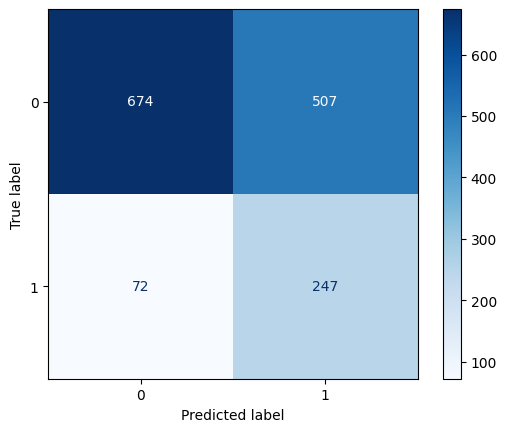

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_val, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1'])
disp.plot(cmap=plt.cm.Blues)
plt.show()